# VCM-based (MCS) CDAC — Sizing & Equation Derivations

**Block:** `saradc` CDAC (NanoVolt, GF180MCU `gf180mcuD`), 10-bit differential SAR.
**Switching:** VCM-based / **Merged-Capacitor Switching (MCS)** — top-plate sampling, MSB resolved for free, each bit cap switches `vrefp / vcm / vrefn`.
**References:**
- V. Hariprasath et al., *"Merged capacitor switching based SAR ADC with highest switching energy-efficiency,"* Electron. Lett., 2010.
- C.-C. Liu et al., *"A 10-bit 50-MS/s SAR ADC with a monotonic capacitor switching procedure,"* JSSC 2010.
- M. Saberi et al., *"Analysis of power consumption and linearity in capacitive DACs used in SAR ADCs,"* TCAS-I 2011.

This notebook (1) **derives** every equation that sizes the array — LSB, kT/C noise, unit-cap matching → DNL/INL, reference settling, switching energy — and (2) **turns them into numbers** for GF180 MIM caps, then recommends a unit cap `Cu`.

> **Working assumptions** (edit in the config cell): VREF = 2.5 V, full-scale differential = 2.0 V_pp, MIM density 2.0 fF/µm² (`cap_mim_2f0fF`). The MIM **matching coefficient `A_C` is a placeholder** (~0.5 %·µm typical) — GF180 does not give it in a datasheet table; extract from the PDK mismatch model / Monte-Carlo. The ngspice model's mismatch is `agauss(0, 0.025, 3)` → **σ = 0.83 % per instance, area-independent** (a model simplification — see §C).

## 0. Specifications

| Parameter | Value | Drives |
|---|---|---|
| Resolution N | 10 bit | LSB, matching, # caps |
| Sample rate f_s | 10 MS/s | bit-trial / settling budget |
| Full scale (diff) | 2.0 V_pp | LSB |
| Reference V_ref | 1.0 V | DAC steps, switching energy |
| SNDR | ≥ 55 dB | kT/C noise budget |
| ENOB | ≥ 9 bit | DNL/INL target (<0.5 LSB) |
| Total ADC power | < 300 µW | **caps switching energy** |
| Switching | VCM-based (MCS) | array = 2^(N-1) units/side |

Schematic (`cap_array.sch`) **resized to Cu = 10 fF** (step 3, 2.236 µm sq) → 512 units/side → 5.12 pF/side. **Why not the old 400 fF or the originally-planned ~2 fF:** with the corrected **VREF = 1.0 V** (was a stale 2.5 V here; the SAR uses vrefp=1/vrefn=0), the MCS switching-energy ceiling rises to ~29 fF, so 400 fF blows the power budget while ~2 fF (1 µm side) risks the MIM-min DRC and worst matching. **Cu = 10 fF** sits comfortably under the energy ceiling, keeps a DRC-safe 2.24 µm geometry, and still cuts area/energy ~40×. Matching (DNL/INL) is verified separately by Monte-Carlo (section G / step 5).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import constants as sc

# ---- physical constants ----
k  = sc.Boltzmann          # [J/K]
T  = 300.0                 # [K] design choice (~27 C); a corner variable
kT = k*T

# ---- ADC specs ----
N        = 10
fs       = 10e6
FS_diff  = 2.0             # full-scale differential [Vpp]
VREF     = 1.0
SNDR_dB  = 55.0
P_adc    = 300e-6          # total ADC power budget [W]

# ---- MIM cap technology (cap_mim_2f0fF) ----
Cdens    = 2.0e-15         # 2.0 fF/um^2 = 2.0e-15 F per um^2
A_C      = 0.5e-2          # cap matching coeff [unitless * um]  (PLACEHOLDER, ~0.5%.um)
sigma_u_model = 0.025/3    # GF180 ngspice mismatch: agauss(0,0.025,3) -> 1-sigma, per instance

# ---- current schematic choice ----
Cu_now   = 10e-15        # resized 400fF->10fF (step 3); see note below

# ---- timing assumption ----
t_settle_frac = 0.5        # fraction of Ts spent converting (rest = sampling)
LSB = FS_diff/2**N
print(f"LSB (diff) = {LSB*1e3:.4f} mV   |   Ts = {1/fs*1e9:.0f} ns")

LSB (diff) = 1.9531 mV   |   Ts = 100 ns


## A. From ADC specs to CDAC budgets

### A.1 LSB
$$\mathrm{LSB}=\frac{V_\mathrm{FS,diff}}{2^{N}}=\frac{2.0}{1024}=1.953\ \mathrm{mV}.$$
Every static error (matching) and dynamic error (settling, noise) is judged against this.

### A.2 kT/C sampling-noise budget (from SNDR)
The total in-band noise+distortion must satisfy
$$V_{n,\mathrm{tot}}\le \frac{V_\mathrm{sig,rms}}{10^{\mathrm{SNDR}/20}},\qquad V_\mathrm{sig,rms}=\frac{V_\mathrm{FS,diff}/2}{\sqrt2}.$$
Quantization already spends $\;\mathrm{LSB}/\sqrt{12}$, so the **circuit** budget is the RSS remainder
$$V_{n,\mathrm{ckt}}=\sqrt{V_{n,\mathrm{tot}}^2-\big(\mathrm{LSB}/\sqrt{12}\big)^2}.$$
The CDAC contributes **sampled kT/C noise**. Top-plate sampling puts the *whole* array $C_\mathrm{tot}=2^{N-1}C_u$ on each side, and the two differential samples are independent:
$$\boxed{\;\sigma_{samp}=\sqrt{\dfrac{2kT}{C_\mathrm{tot}}}\;}\qquad\Rightarrow\qquad C_\mathrm{tot,min}=\dfrac{2kT}{\sigma_{budget}^2}.$$
**Lesson:** kT/C sets a *floor* on total C. We will see it is a tiny floor — matching and energy dominate.

### A.3 Bit-trial (settling) budget
A SAR uses one sample phase + $N$ bit-trials per period $T_s=1/f_s$. With a fraction $f$ of $T_s$ for conversion,
$$\boxed{\;t_{bit}=\dfrac{f\,T_s}{N}\;}.$$
The reference must settle the switched cap to $<\tfrac12\mathrm{LSB}$ inside $t_{bit}$ (§E).

In [2]:
# A.2 noise budget
Vsig_rms = (FS_diff/2)/np.sqrt(2)
Vn_tot   = Vsig_rms/10**(SNDR_dB/20)
Vn_quant = LSB/np.sqrt(12)
Vn_ckt   = np.sqrt(Vn_tot**2 - Vn_quant**2)
# allocate (say) half the circuit noise power to the CDAC sampling, half to comparator
Vn_samp_budget = Vn_ckt/np.sqrt(2)
Ctot_min_noise = 2*kT/Vn_samp_budget**2

# A.3 bit-trial time
t_bit = t_settle_frac*(1/fs)/N

print(f"signal rms           = {Vsig_rms*1e3:.1f} mV")
print(f"total N+D budget     = {Vn_tot*1e3:.3f} mV")
print(f"quantization noise   = {Vn_quant*1e3:.3f} mV")
print(f"circuit noise budget = {Vn_ckt*1e3:.3f} mV   -> CDAC share {Vn_samp_budget*1e3:.3f} mV")
print(f"=> Ctot_min (kT/C)   = {Ctot_min_noise*1e15:.2f} fF  (per side)   <-- tiny!")
print(f"bit-trial time t_bit = {t_bit*1e9:.2f} ns  (f={t_settle_frac} of Ts over {N} bits)")

signal rms           = 707.1 mV
total N+D budget     = 1.257 mV
quantization noise   = 0.564 mV
circuit noise budget = 1.124 mV   -> CDAC share 0.795 mV
=> Ctot_min (kT/C)   = 13.12 fF  (per side)   <-- tiny!
bit-trial time t_bit = 5.00 ns  (f=0.5 of Ts over 10 bits)


## B. The MCS array, derived

### B.1 Why MCS needs half the caps
Conventional binary needs unit-cap weights $2^{N-1}\dots2^0$ plus a dummy = $2^{N}$ units/side. In MCS the **first comparison is made on the sampled input with all bottom plates at $v_{cm}$** (no switching), so the MSB is free and the *largest cap ever switched* is $2^{N-2}$. Per side:
$$\underbrace{2^{N-2}+\dots+2^0}_{N-1\ \text{caps}}+\underbrace{1}_{\text{dummy}}=2^{N-1}\ \text{units}.$$
$$\boxed{\,C_\mathrm{tot}=2^{N-1}C_u\ \text{(per side)},\qquad \text{half of conventional }2^{N}C_u\,}$$

### B.2 Common-mode constancy
At each trial the higher-side cap moves $v_{cm}\!\to\!v_{refp}$ (+) while its twin moves $v_{cm}\!\to\!v_{refn}$ (−) by the *same* weight. The two top plates move $\pm\Delta$, so $(v_{top,p}+v_{top,n})/2$ is invariant — the comparator common mode never moves. (Confirmed in `cdac_func.spice`: CM pinned at 1.250 V across all phases.)

### B.3 DAC step (verifies the array)
Switching a cap of weight $w$ from $v_{cm}$ to $v_{refp}$ on one side and its twin to $v_{refn}$ on the other moves the differential top-plate by
$$\Delta v_{diff}=\frac{w}{C_\mathrm{tot}}\,(v_{refp}-v_{refn})=\frac{w}{2^{N-1}}\,V_\mathrm{ref}.$$
For $w=2^{N-2}$ (first switched bit): $\Delta v=V_\mathrm{ref}/2$. (Sim: MSB→1.250 V, bit-6→+0.3125 V — exactly $256/512$ and $64/512$ of $V_\mathrm{ref}$.)

In [3]:
units_per_side = 2**(N-1)
Ctot_now = units_per_side*Cu_now
print(f"units/side          = {units_per_side}")
print(f"Ctot/side (Cu=400f) = {Ctot_now*1e12:.1f} pF   (total diff ~ {2*Ctot_now*1e12:.0f} pF)")
print(f"unit cap area       = {Cu_now/Cdens:.1f} um^2  ({np.sqrt(Cu_now/Cdens):.2f} um square)")
# DAC step check
for w in (2**(N-2), 64):
    print(f"  weight {w:4d} -> dVdiff = {w/units_per_side*VREF:.4f} V")

units/side          = 512
Ctot/side (Cu=400f) = 5.1 pF   (total diff ~ 10 pF)
unit cap area       = 5.0 um^2  (2.24 um square)
  weight  256 -> dVdiff = 0.5000 V
  weight   64 -> dVdiff = 0.1250 V


## C. Unit-cap matching → DNL / INL, derived

Let the **per-unit-cap relative mismatch** be $\sigma_u=\sigma(C_u)/C_u$ (independent across units). A binary cap of weight $w$ is $w$ unit caps in parallel, so its relative mismatch averages down as $\sigma_u/\sqrt{w}$.

**DNL.** The worst code transition is the MSB one ($0111\!\dots\!1\to1000\!\dots\!0$): one $2^{N-1}$-cap switches in while all $2^{N-1}\!-\!1$ lower units switch out — $2^{N}\!-\!1$ units change state. Their cap errors are independent, so
$$\boxed{\;\sigma(\mathrm{DNL})_\mathrm{max}=\sqrt{2^{N}-1}\;\sigma_u\;\;[\mathrm{LSB}]\;}$$

**INL.** Worst at mid-code (sum of the connected units' errors):
$$\boxed{\;\sigma(\mathrm{INL})_\mathrm{max}=\tfrac12\sqrt{2^{N}-1}\;\sigma_u\;\;[\mathrm{LSB}]\;}$$

**Matching → area (Pelgrom).** Physically $\sigma_u=A_C/\sqrt{\mathrm{Area}}$, so a DNL target sets a *minimum* unit area:
$$\sigma(\mathrm{DNL})_\mathrm{max}<\tfrac12\,\mathrm{LSB}\ \Rightarrow\ \sigma_u<\frac{0.5}{\sqrt{2^N-1}}\ \Rightarrow\ \boxed{\;\mathrm{Area}_{u,\min}=\Big(\frac{A_C}{\sigma_{u,\max}}\Big)^2\;}$$

> **GF180 caveat:** the ngspice MIM model applies mismatch as $C(1+\delta)$ with $\delta=\texttt{agauss}(0,0.025,3)\Rightarrow\sigma=0.83\%$ **independent of area**. So in *simulation* matching does not improve with size — you must trust silicon/Pelgrom data (the $A_C/\sqrt{\mathrm{Area}}$ law) for real area sizing, and decompose binary caps into unit caps (or scale $\sigma$ by $1/\sqrt{w}$) so the model averages correctly.

In [4]:
sigma_dnl = lambda su: np.sqrt(2**N-1)*su
sigma_inl = lambda su: 0.5*np.sqrt(2**N-1)*su
su_max    = 0.5/np.sqrt(2**N-1)            # for sigma(DNL)<0.5 LSB

print(f"need sigma_u < {su_max*100:.2f} %  for sigma(DNL) < 0.5 LSB")
print(f"with model sigma_u = {sigma_u_model*100:.2f} %:")
print(f"   sigma(DNL)_max ~ {sigma_dnl(sigma_u_model):.3f} LSB")
print(f"   sigma(INL)_max ~ {sigma_inl(sigma_u_model):.3f} LSB")
# area to hit su_max with placeholder A_C
Area_min = (A_C/su_max)**2
print(f"Pelgrom (A_C={A_C*100:.2f}%.um): Area_u,min = {Area_min:.3f} um^2 -> Cu_min(match) = {Area_min*Cdens*1e15:.2f} fF")

need sigma_u < 1.56 %  for sigma(DNL) < 0.5 LSB
with model sigma_u = 0.83 %:
   sigma(DNL)_max ~ 0.267 LSB
   sigma(INL)_max ~ 0.133 LSB
Pelgrom (A_C=0.50%.um): Area_u,min = 0.102 um^2 -> Cu_min(match) = 0.20 fF


## D. Switching energy → the real constraint on $C_u$

Charge drawn from the reference each conversion costs $E=\sum \Delta Q\,V_\mathrm{ref}$. Averaged over uniformly-distributed codes, the published normalized energies (in $C_uV_\mathrm{ref}^2$) for a 10-bit array are:

| scheme | $E_\mathrm{avg}/(C_uV_\mathrm{ref}^2)$ | vs conventional |
|---|---|---|
| Conventional | 1363 | — |
| Monotonic (set-and-down) | 256 | −81 % |
| **VCM-based / MCS** | **170** | **−87 %** |

So $E_\mathrm{MCS}\approx170\,C_uV_\mathrm{ref}^2$ and the DAC's switching **power** is $P=E\,f_s$. With $C_u=400$ fF this *alone* dwarfs the 300 µW budget — pushing $C_u$ **down**. Matching (model) and kT/C allow tiny caps; energy, plus a layout floor (process-min MIM and the **parasitic-ratio** $C_\mathrm{par}/C_\mathrm{tot}$ gain error), set the practical window.

In [5]:
E_coeff = {'conventional':1363.0, 'monotonic':256.0, 'MCS':170.0}
def P_switch(Cu, scheme='MCS'):
    return E_coeff[scheme]*Cu*VREF**2*fs

for s in E_coeff:
    print(f"{s:13s}: E={E_coeff[s]*Cu_now*VREF**2*1e12:7.2f} pJ   P={P_switch(Cu_now,s)*1e3:7.3f} mW   (Cu=400fF)")

# Cu that fits a chosen DAC-power share (e.g. 1/6 of the 300 uW budget)
P_dac_budget = P_adc/6
Cu_energy_max = P_dac_budget/(E_coeff['MCS']*VREF**2*fs)
print(f"\nFor P_dac < {P_dac_budget*1e6:.0f} uW (MCS): Cu_max(energy) = {Cu_energy_max*1e15:.2f} fF")
print(f"=> Cu=400 fF is ~{Cu_now/Cu_energy_max:.0f}x too large on the energy budget.")

conventional : E=  13.63 pJ   P=  0.136 mW   (Cu=400fF)
monotonic    : E=   2.56 pJ   P=  0.026 mW   (Cu=400fF)
MCS          : E=   1.70 pJ   P=  0.017 mW   (Cu=400fF)

For P_dac < 50 uW (MCS): Cu_max(energy) = 29.41 fF
=> Cu=400 fF is ~0x too large on the energy budget.


## E. Reference settling

When a bit cap of weight $w$ switches, the reference (buffer output + switch $R_\mathrm{on}$) must charge it through $R$ with $\tau=R\,C_{sw}$, $C_{sw}\approx w\,C_u$. To settle a step $\Delta V$ to $<\tfrac12\mathrm{LSB}$:
$$\Delta V\,e^{-t_{bit}/\tau}<\tfrac12\mathrm{LSB}\ \Rightarrow\ \frac{t_{bit}}{\tau}>\ln\!\frac{\Delta V}{\tfrac12\mathrm{LSB}}\equiv n_\tau.$$
Worst case $\Delta V=V_\mathrm{ref}$ (MSB), so
$$\boxed{\;n_\tau=\ln\!\frac{2V_\mathrm{ref}}{\mathrm{LSB}},\qquad R_\mathrm{max}=\frac{t_{bit}}{n_\tau\,(2^{N-2}C_u)}\;}$$
**Lesson:** shrinking $C_u$ relaxes the reference resistance *and* the energy — both push the same way. A large on-chip decoupling cap supplies the instantaneous charge and lets the buffer recharge between trials.

In [6]:
n_tau = np.log(2*VREF/LSB)
def R_max(Cu):
    return t_bit/(n_tau*(2**(N-2)*Cu))
print(f"settling time constants needed n_tau = {n_tau:.2f}")
for Cu in (Cu_now, 40e-15, 4e-15):
    print(f"  Cu={Cu*1e15:6.1f} fF  Csw(MSB)={2**(N-2)*Cu*1e12:6.3f} pF  -> R_max = {R_max(Cu):8.1f} ohm")

settling time constants needed n_tau = 6.93
  Cu=  10.0 fF  Csw(MSB)= 2.560 pF  -> R_max =    281.8 ohm
  Cu=  40.0 fF  Csw(MSB)=10.240 pF  -> R_max =     70.4 ohm
  Cu=   4.0 fF  Csw(MSB)= 1.024 pF  -> R_max =    704.4 ohm


## F. The $C_u$ window — pick the unit cap

Sweep $C_u$ and overlay the three constraints: switching power (must be $<$ budget), reference $R_\mathrm{max}$ (must be reachable by the buffer), and matching DNL (Pelgrom, area-scaled). The feasible $C_u$ is bounded **below** by matching/parasitic floor and **above** by energy.

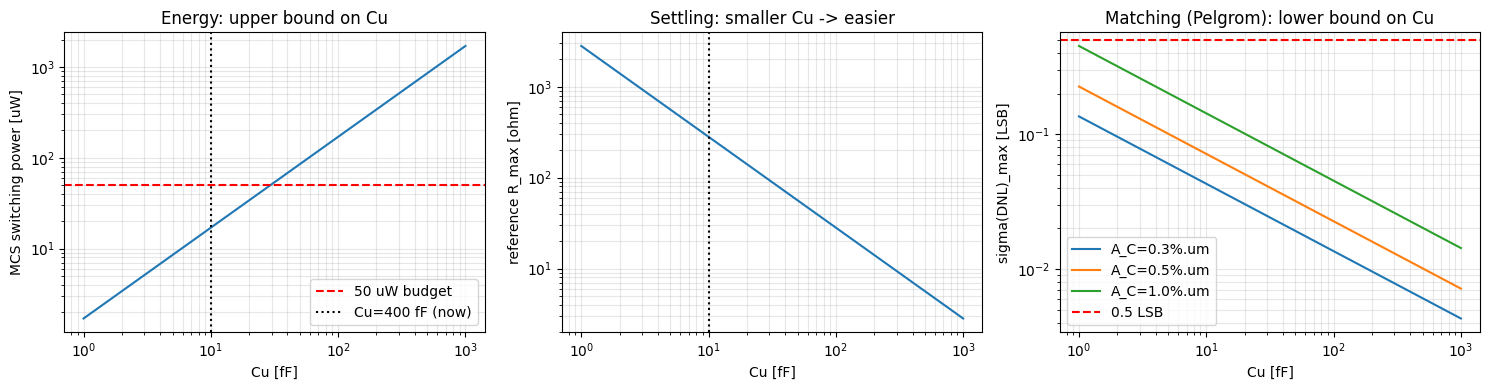

Cu_match (3-sigma DNL<0.5LSB, A_C=0.5%) = 1.84 fF
parasitic/min-geometry floor              = 2.0 fF
energy ceiling Cu_max                      = 29.41 fF
RECOMMENDED Cu ~ 2.0 fF  -> feasible (<= energy ceiling)
   area = 1.00 um^2 (1.00 um square)


In [7]:
Cu = np.logspace(np.log10(1e-15), np.log10(1e-12), 200)
fig, ax = plt.subplots(1, 3, figsize=(15,4))

ax[0].loglog(Cu*1e15, P_switch(Cu)*1e6)
ax[0].axhline(P_dac_budget*1e6, ls='--', c='r', label=f'{P_dac_budget*1e6:.0f} uW budget')
ax[0].axvline(Cu_now*1e15, ls=':', c='k', label='Cu=400 fF (now)')
ax[0].set(xlabel='Cu [fF]', ylabel='MCS switching power [uW]', title='Energy: upper bound on Cu'); ax[0].legend(); ax[0].grid(True, which='both', alpha=.3)

ax[1].loglog(Cu*1e15, R_max(Cu))
ax[1].axvline(Cu_now*1e15, ls=':', c='k')
ax[1].set(xlabel='Cu [fF]', ylabel='reference R_max [ohm]', title='Settling: smaller Cu -> easier'); ax[1].grid(True, which='both', alpha=.3)

# matching DNL with area-scaled Pelgrom (physical), per A_C value
for ac in (0.3e-2, 0.5e-2, 1.0e-2):
    su = ac/np.sqrt(Cu/Cdens)
    ax[2].loglog(Cu*1e15, sigma_dnl(su), label=f'A_C={ac*100:.1f}%.um')
ax[2].axhline(0.5, ls='--', c='r', label='0.5 LSB')
ax[2].set(xlabel='Cu [fF]', ylabel='sigma(DNL)_max [LSB]', title='Matching (Pelgrom): lower bound on Cu'); ax[2].legend(); ax[2].grid(True, which='both', alpha=.3)
plt.tight_layout(); plt.show()

# recommendation: smallest Cu meeting matching (3-sigma DNL<0.5LSB) and a parasitic floor,
# checked against the energy ceiling.
su_target = 0.5/3/np.sqrt(2**N-1)          # 3-sigma DNL < 0.5 LSB
Cu_match  = (A_C/su_target)**2*Cdens
Cu_floor  = 2e-15                          # process/parasitic-ratio floor (CONFIRM via DRC + layout)
Cu_reco   = max(Cu_match, Cu_floor)
print(f"Cu_match (3-sigma DNL<0.5LSB, A_C={A_C*100:.1f}%) = {Cu_match*1e15:.2f} fF")
print(f"parasitic/min-geometry floor              = {Cu_floor*1e15:.1f} fF")
print(f"energy ceiling Cu_max                      = {Cu_energy_max*1e15:.2f} fF")
print(f"RECOMMENDED Cu ~ {Cu_reco*1e15:.1f} fF  -> {'feasible (<= energy ceiling)' if Cu_reco<=Cu_energy_max else 'CONFLICT: > energy ceiling, relax power share / VREF'}")
print(f"   area = {Cu_reco/Cdens:.2f} um^2 ({np.sqrt(Cu_reco/Cdens):.2f} um square)")

## G. DNL / INL Monte-Carlo (numpy)

Build the binary array from independent unit caps with relative mismatch $\sigma_u$, sweep all codes, and histogram the worst-case |DNL|, |INL|. This is the same model `ngspice` would run with `.mc` — but instant. (For the real PDK number, run the ngspice Monte-Carlo on `cdac.sch` with `sw_stat_global=1`.)

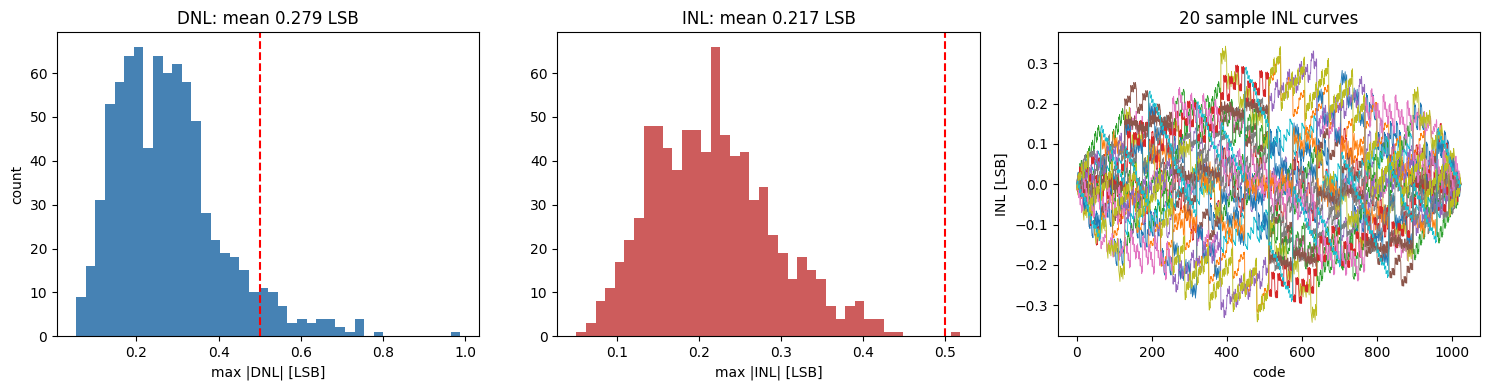

MC  sigma_u=0.83% : <max DNL>=0.279  <max INL>=0.217 LSB
analytic       : sigma(DNL)=0.267  sigma(INL)=0.133 LSB


In [8]:
def mc_dnl_inl(sigma_u, trials=800, seed=0):
    rng  = np.random.default_rng(seed)
    w    = 2**np.arange(N-1, -1, -1)                 # binary weights, MSB first (sum = 2^N - 1)
    Wtot = int(w.sum())                              # 2^N - 1 unit caps
    idx  = np.concatenate([[0], np.cumsum(w)])
    units = rng.normal(1.0, sigma_u, (trials, Wtot)) # each unit cap, relative
    bcap  = np.stack([units[:, idx[i]:idx[i+1]].sum(1) for i in range(N)], axis=1)  # (trials,N)
    ctot  = bcap.sum(1, keepdims=True)
    codes = np.arange(2**N)                          # 2^N codes 0..2^N-1
    bits  = ((codes[:,None] >> np.arange(N-1,-1,-1)[None,:]) & 1).astype(float)     # (2^N,N)
    Vout  = (bits @ bcap.T)/ctot.T * Wtot           # ideal Vout(code)=code [LSB]
    dnl   = np.diff(Vout, axis=0) - 1.0
    inl   = Vout - codes[:,None]
    return dnl, inl, Vout

dnl, inl, Vout = mc_dnl_inl(sigma_u_model)
dnl_max = np.abs(dnl).max(0); inl_max = np.abs(inl).max(0)

fig, ax = plt.subplots(1, 3, figsize=(15,4))
ax[0].hist(dnl_max, 40, color='steelblue'); ax[0].axvline(0.5, ls='--', c='r')
ax[0].set(xlabel='max |DNL| [LSB]', ylabel='count', title=f'DNL: mean {dnl_max.mean():.3f} LSB')
ax[1].hist(inl_max, 40, color='indianred'); ax[1].axvline(0.5, ls='--', c='r')
ax[1].set(xlabel='max |INL| [LSB]', title=f'INL: mean {inl_max.mean():.3f} LSB')
ax[2].plot(inl[:, :20], lw=.6); ax[2].set(xlabel='code', ylabel='INL [LSB]', title='20 sample INL curves')
plt.tight_layout(); plt.show()

print(f"MC  sigma_u={sigma_u_model*100:.2f}% : <max DNL>={dnl_max.mean():.3f}  <max INL>={inl_max.mean():.3f} LSB")
print(f"analytic       : sigma(DNL)={sigma_dnl(sigma_u_model):.3f}  sigma(INL)={sigma_inl(sigma_u_model):.3f} LSB")

## H. Summary & recommended sizing

In [9]:
rows = [
 ("LSB (diff)",              f"{LSB*1e3:.3f} mV",            "FS/2^N"),
 ("units / side",           f"{units_per_side}",            "MCS = 2^(N-1)"),
 ("Ctot,min (kT/C)",        f"{Ctot_min_noise*1e15:.1f} fF","noise floor (negligible)"),
 ("sigma_u needed",         f"< {su_max*100:.2f} %",        "for sigma(DNL)<0.5 LSB"),
 ("sigma_u (ngspice model)",f"{sigma_u_model*100:.2f} %",   "agauss(0,0.025,3), area-indep."),
 ("sigma(DNL)/(INL) model", f"{sigma_dnl(sigma_u_model):.2f} / {sigma_inl(sigma_u_model):.2f} LSB","analytic"),
 ("Cu_max (energy)",        f"{Cu_energy_max*1e15:.1f} fF", f"P_dac<{P_dac_budget*1e6:.0f}uW, MCS"),
 ("Cu_min (matching)",      f"{Cu_match*1e15:.2f} fF",      f"3-sig DNL, A_C={A_C*100:.1f}%.um"),
 ("Cu RECOMMENDED",         f"~{Cu_reco*1e15:.1f} fF",      ">=matching, >=floor, <=energy ceiling"),
 ("Cu in schematic now",    f"{Cu_now*1e15:.0f} fF",        "REVISIT: energy-prohibitive"),
 ("Ctot/side @ Cu_reco",    f"{units_per_side*Cu_reco*1e12:.2f} pF", ""),
 ("P_switch @ Cu_reco",     f"{P_switch(Cu_reco)*1e6:.1f} uW", "MCS"),
 ("ref R_max @ Cu_reco",    f"{R_max(Cu_reco):.0f} ohm",    f"t_bit={t_bit*1e9:.1f} ns"),
]
df = pd.DataFrame(rows, columns=["quantity","value","note"])
print(df.to_string(index=False))
print(f"\nSUMMARY: 400 fF is ~{Cu_now/Cu_energy_max:.0f}x over the energy budget; matching+noise allow"
      f" few-fF units, so Cu is set by the layout/parasitic floor (~{Cu_reco*1e15:.1f} fF), giving"
      f" ~{units_per_side*Cu_reco*1e12:.2f} pF/side and ~{P_switch(Cu_reco)*1e6:.0f} uW switching.")

               quantity           value                                  note
             LSB (diff)        1.953 mV                                FS/2^N
           units / side             512                         MCS = 2^(N-1)
        Ctot,min (kT/C)         13.1 fF              noise floor (negligible)
         sigma_u needed        < 1.56 %                for sigma(DNL)<0.5 LSB
sigma_u (ngspice model)          0.83 %        agauss(0,0.025,3), area-indep.
 sigma(DNL)/(INL) model 0.27 / 0.13 LSB                              analytic
        Cu_max (energy)         29.4 fF                       P_dac<50uW, MCS
      Cu_min (matching)         1.84 fF                3-sig DNL, A_C=0.5%.um
         Cu RECOMMENDED         ~2.0 fF >=matching, >=floor, <=energy ceiling
    Cu in schematic now           10 fF           REVISIT: energy-prohibitive
    Ctot/side @ Cu_reco         1.02 pF                                      
     P_switch @ Cu_reco          3.4 uW                         

## I. Caveats & verification testbenches

- **`A_C` is a placeholder (~0.5 %·µm).** Extract the real GF180 MIM matching from the PDK mismatch model (the `agauss` in `mimcap_statistical`) or silicon. The ngspice model's mismatch is **area-independent (0.83 %)** — do *not* trust it for area sizing; it is only right if you decompose binary caps into independent unit caps (m=1) or scale by $1/\sqrt{w}$.
- **400 fF is energy-prohibitive.** This notebook recommends shrinking `Cu` toward the layout/parasitic floor (~few–10 fF). Before changing `cap_array.sch`, confirm the **parasitic-ratio** $C_\mathrm{par}/C_\mathrm{tot}$ (top-plate routing + comparator input cap) stays small — that, not matching/noise, is usually the real lower bound. Re-pick `W=L` for the new `Cu` (`Area=Cu/2.0fF·µm⁻²`).
- **Settling** assumes a single-pole $RC$ and worst-case MSB step. Verify with the reference buffer + switch $R_\mathrm{on}$ in the loop, and add the on-chip decoupling cap.
- **Switching-energy coefficients** (170 / 256 / 1363) are average-over-codes from the literature — confirm with a transient that integrates $i_\mathrm{ref}\cdot V_\mathrm{ref}$ over a full conversion.

**Testbenches to build in `saradc/tb/`:**
1. **DNL/INL ngspice Monte-Carlo** on `cdac.sch` (set `sw_stat_global=1`, sweep all/representative codes, ≥200 runs) — compare to §G.
2. **Reference settling** — drive a bottom plate through a realistic $R_\mathrm{ref}$+$R_\mathrm{on}$; measure top-plate error at $t_{bit}$ vs §E.
3. **Switching energy** — integrate reference current over a conversion for MCS; compare to §D.
4. **Full SAR loop** — wrap `cdac.sym` + `comparator.sym` + SAR logic; check ENOB from an FFT (extends `cdac_func.spice`).
5. **kT/C / parasitics** — extract top-plate parasitic from layout; confirm gain error and noise.